In [137]:
# importing libraries
import math
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline


train=pd.read_csv("EvoChargeNaive.csv")
xls =pd.read_excel("BTS Data.xlsx")

In [138]:
xls_elec =pd.read_excel("fotw1275webxlsx.xlsx")
xls_elec.rename(
    columns={
        "Month-Year": "Date",
        "Electric Vehicles": "Monthly_EV_market_share%",
        "Plug-In Hybrid Electric Vehicles": "Monthly_PHEV_market_share%"
    },
    inplace=True
)

xls_elec=xls_elec.iloc[:, :-1]

    The instruction (in Spanish) means you must reconstruct monthly sales of PHEVs and EVs from Jan-2010 to Dec-2022 using two pieces of information in BTS Data.xlsx:
    
    Total vehicle sales per year (in millions of units) in the United States from 2010–2022.
    
    Average proportion of annual sales that occur in each month (Jan–Dec).
    
    Core Idea
    
    You distribute each year's total sales across the 12 months using the monthly proportions.
    
    So for each year:
    
    Monthly Salesy,m=Annual Salesy×Monthly Proportionm
    Monthly Sales
    y,m
    	​
    
    =Annual Sales
    y
    	​
    
    ×Monthly Proportion
    m
    	​
    
    
    Where:
    
    y
    y = year (2010–2022)
    
    m
    m = month (Jan–Dec)
    
    If proportions are percentages, convert them to decimals first.

In [139]:
# Remove the last row
xls = xls.iloc[:-1, :]

# Set "Year" as the index and drop the column
xls = xls.set_index("Year", drop=True)

# Display the dataframe
xls_1= xls.loc[:, ["Vehicles Sold (millions)"]]

xls_2= xls.loc[:, ["Month","\nAverage proportion of sales made each month"]].head(12)

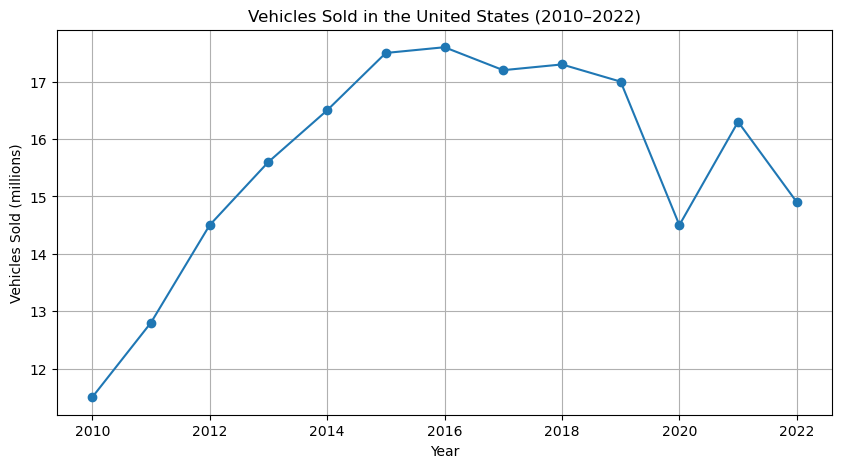

In [140]:
# Plot
plt.figure(figsize=(10,5))
plt.plot( xls_1["Vehicles Sold (millions)"], marker="o")

plt.title("Vehicles Sold in the United States (2010–2022)")
plt.xlabel("Year")
plt.ylabel("Vehicles Sold (millions)")
plt.grid(True)

plt.show()

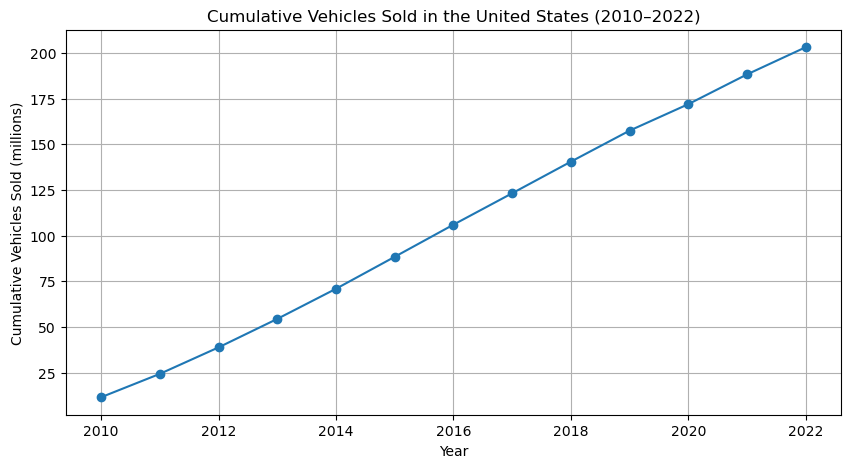

In [141]:
# Compute cumulative sum
xls_1["Cumulative Vehicles Sold (millions)"] = xls_1["Vehicles Sold (millions)"].cumsum()

# Plot
plt.figure(figsize=(10,5))
plt.plot(xls_1["Cumulative Vehicles Sold (millions)"], marker="o")

plt.title("Cumulative Vehicles Sold in the United States (2010–2022)")
plt.xlabel("Year")
plt.ylabel("Cumulative Vehicles Sold (millions)")
plt.grid(True)

plt.show()

In [142]:
xls_1.reset_index(inplace=True)

# -----------------------
# Train model
# -----------------------
X = xls_1[["Year"]]
y = xls_1["Vehicles Sold (millions)"]

Forecast Vehicles Sold in 2023: 17.3 million


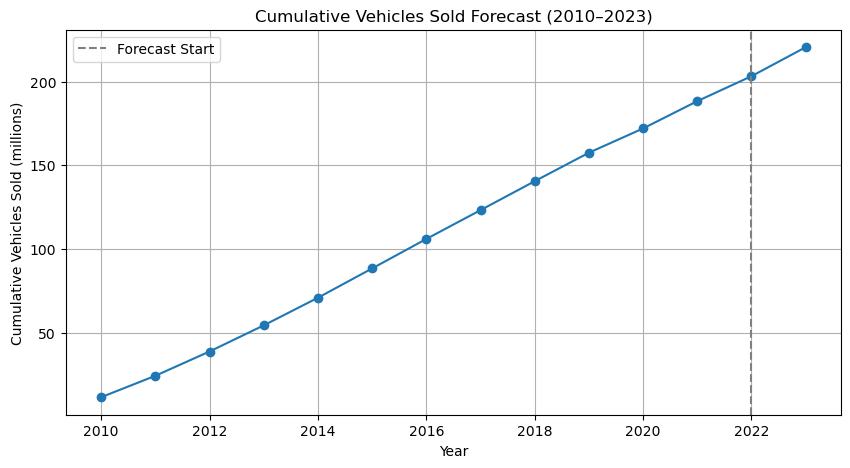

In [143]:
from sklearn.linear_model import LinearRegression

df=xls_1

model = LinearRegression()
model.fit(X, y)

# -----------------------
# Forecast 2023
# -----------------------
forecast_2023 = model.predict([[2023]])[0]

print("Forecast Vehicles Sold in 2023:", round(forecast_2023,2), "million")

# -----------------------
# Add forecast to dataframe
# -----------------------
df_future = pd.DataFrame({
    "Year":[2023],
    "Vehicles Sold (millions)":[forecast_2023]
})

df_all = pd.concat([df, df_future], ignore_index=True)

# -----------------------
# Cumulative sum
# -----------------------
df_all["Cumulative Vehicles Sold (millions)"] = df_all["Vehicles Sold (millions)"].cumsum()

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(10,5))

plt.plot(df_all["Year"], df_all["Cumulative Vehicles Sold (millions)"], marker="o")

plt.axvline(2022, linestyle="--", color="gray", label="Forecast Start")

plt.title("Cumulative Vehicles Sold Forecast (2010–2023)")
plt.xlabel("Year")
plt.ylabel("Cumulative Vehicles Sold (millions)")
plt.legend()
plt.grid(True)

plt.show()

In [144]:
forecast_2023

np.float64(17.30000000000001)

In [145]:
import pandas as pd
import numpy as np

# predicted 2023 yearly value (example from regression)
forecast_2023 = forecast_2023# million vehicles

# Monthly proportions
data = {
    "Month":[
        "January","February","March","April","May","June",
        "July","August","September","October","November","December"
    ],
    "Proportion":[
        0.0631,0.0663,0.0839,0.0770,0.0755,0.0952,
        0.0886,0.0809,0.0920,0.0898,0.0887,0.0990
    ]
}

df_month = pd.DataFrame(data)

# multiply with yearly forecast
df_month["Vehicles Sold (millions)"] = forecast_2023 * df_month["Proportion"]

# create monthly dates
dates = pd.date_range("2023-01-01", periods=12, freq="MS")

df_month["Date"] = dates
df_month = df_month.set_index("Date")

df_month["Vehicles Sold (millions)"]=df_month["Vehicles Sold (millions)"]*1000000

print(df_month)

                Month  Proportion  Vehicles Sold (millions)
Date                                                       
2023-01-01    January      0.0631                 1091630.0
2023-02-01   February      0.0663                 1146990.0
2023-03-01      March      0.0839                 1451470.0
2023-04-01      April      0.0770                 1332100.0
2023-05-01        May      0.0755                 1306150.0
2023-06-01       June      0.0952                 1646960.0
2023-07-01       July      0.0886                 1532780.0
2023-08-01     August      0.0809                 1399570.0
2023-09-01  September      0.0920                 1591600.0
2023-10-01    October      0.0898                 1553540.0
2023-11-01   November      0.0887                 1534510.0
2023-12-01   December      0.0990                 1712700.0


In [146]:
df_sales= xls_1.reset_index()
df_sales["Vehicles Sold"]=df_sales["Vehicles Sold (millions)"]*1000000
df_sales.drop(columns=["Vehicles Sold (millions)"],inplace=True)

In [147]:
# Monthly proportion of sales (sum = 1)
monthly_proportion = xls_2["\nAverage proportion of sales made each month"].astype(float).to_list()

monthly_data = []

for _, row in df_sales.iterrows():
    year = int(row["Year"])
    annual_sales = float(row["Vehicles Sold"])
    
    cumulative = 0  # start at 0 for each year
    for month_index, month_prop in enumerate(monthly_proportion, start=1):
        monthly_sales = annual_sales * month_prop
        cumulative += monthly_sales
        
        monthly_data.append({
            "Date": pd.Timestamp(year=year, month=month_index, day=1),
            "Monthly_Sales": monthly_sales,
            "Cumulative_Sales": cumulative  # cumulative starting from 0 each year
        })

df_monthly = pd.DataFrame(monthly_data)
df_monthly

,Date,Monthly_Sales,Cumulative_Sales
0,2010-01-01,725650.0,725650.0
1,2010-02-01,762450.0,1488100.0
2,2010-03-01,964850.0,2452950.0
3,2010-04-01,885500.0,3338450.0
4,2010-05-01,868250.0,4206700.0
...,...,...,...
151,2022-08-01,1205410.0,9394450.0
152,2022-09-01,1370800.0,10765250.0
153,2022-10-01,1338020.0,12103270.0
154,2022-11-01,1321630.0,13424900.0


In [148]:
# months_df = xls_2[["Month", "\nAverage proportion of sales made each month"]]
# months_df.columns = ["Month","Prop"]

# df_monthly = (
#     df_sales.assign(key=1)
#     .merge(months_df.assign(key=1), on="key")
#     .drop("key", axis=1)
# )

# df_monthly["Monthly_Sales"] = (
#     df_monthly["Vehicles Sold (millions)"] * 1_000_000 * df_monthly["Prop"]
# )

# df_monthly["Date"] = pd.to_datetime(
#     df_monthly["Year"].astype(str) + "-" + df_monthly["Month"] + "-01"
# )

# df_monthly = df_monthly.sort_values("Date")

# df_monthly

In [149]:
# Market share for EVs and PHEVs per year
market_share = pd.DataFrame({
    "Year": list(range(2010, 2023)),
    "EV_Share": [0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.12, 0.13, 0.14, 0.15],
    "PHEV_Share": [0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05, 0.055, 0.06, 0.065, 0.07]
})

# Create monthly dataset
monthly_data_2 = []

for _, row in df_sales.iterrows():
    year = int(row["Year"])
    annual_sales = float(row["Vehicles Sold"])
    
    # Get market shares for this year
    ev_share = float(market_share.loc[market_share["Year"]==year, "EV_Share"])
    phev_share = float(market_share.loc[market_share["Year"]==year, "PHEV_Share"])
    
    cumulative_ev = 0
    cumulative_phev = 0
    
    for month_index, month_prop in enumerate(monthly_proportion, start=1):
        monthly_total = annual_sales * month_prop
        
        # EV and PHEV monthly sales
        monthly_ev = monthly_total * ev_share
        monthly_phev = monthly_total * phev_share
        
        cumulative_ev += monthly_ev
        cumulative_phev += monthly_phev
        
        monthly_data_2.append({
            "Date": pd.Timestamp(year=year, month=month_index, day=1),
            "Monthly_Total": monthly_total,
            "Monthly_EV": monthly_ev,
            "Monthly_PHEV": monthly_phev,
            "Cumulative_EV": cumulative_ev,
            "Cumulative_PHEV": cumulative_phev
        })

df_monthly_2 = pd.DataFrame(monthly_data_2)
df_monthly_2

,Date,Monthly_Total,Monthly_EV,Monthly_PHEV,Cumulative_EV,Cumulative_PHEV
0,2010-01-01,725650.0,14513.0,7256.5,14513.0,7256.5
1,2010-02-01,762450.0,15249.0,7624.5,29762.0,14881.0
2,2010-03-01,964850.0,19297.0,9648.5,49059.0,24529.5
3,2010-04-01,885500.0,17710.0,8855.0,66769.0,33384.5
4,2010-05-01,868250.0,17365.0,8682.5,84134.0,42067.0
...,...,...,...,...,...,...
151,2022-08-01,1205410.0,180811.5,84378.7,1409167.5,657611.5
152,2022-09-01,1370800.0,205620.0,95956.0,1614787.5,753567.5
153,2022-10-01,1338020.0,200703.0,93661.4,1815490.5,847228.9
154,2022-11-01,1321630.0,198244.5,92514.1,2013735.0,939743.0


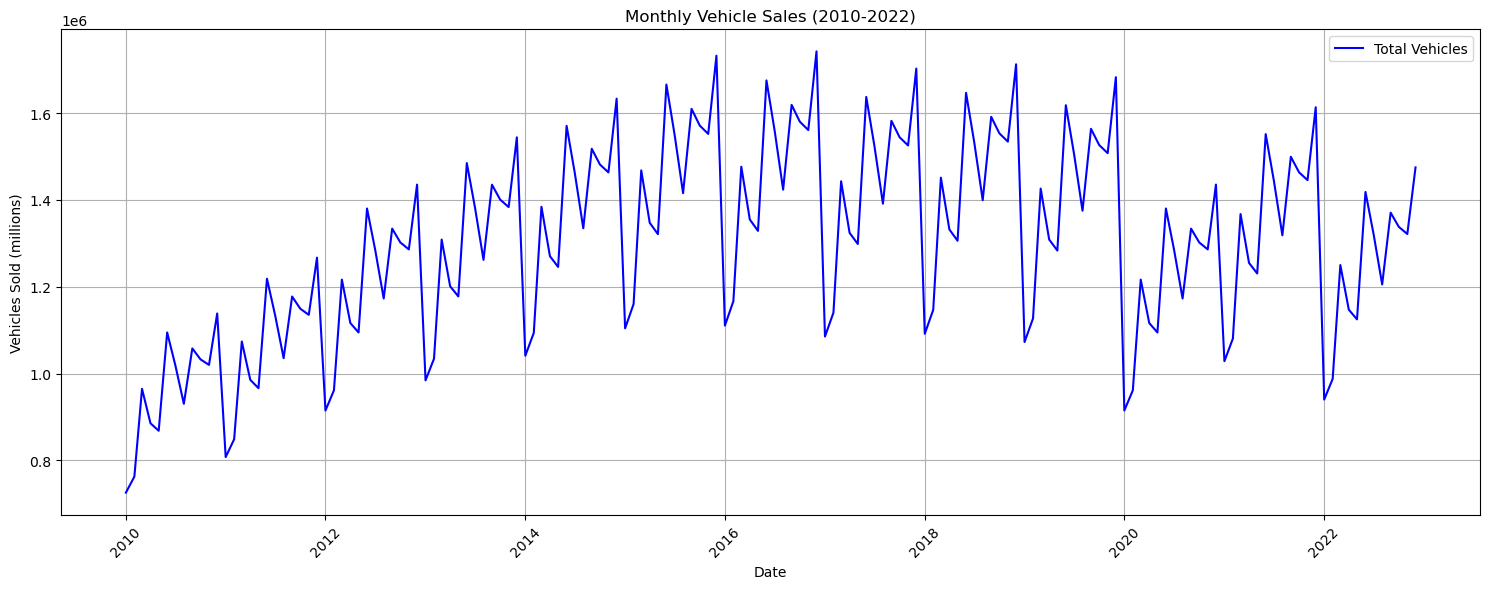

In [150]:
import matplotlib.pyplot as plt

# Set figure size
plt.figure(figsize=(15,6))

# Plot each line
plt.plot(df_monthly_2["Date"], df_monthly_2["Monthly_Total"], label="Total Vehicles", color="blue")
# plt.plot(df_monthly_2["Date"], df_monthly_2["Monthly_EV"], label="EV Sales", color="green")
# plt.plot(df_monthly_2["Date"], df_monthly_2["Monthly_PHEV"], label="PHEV Sales", color="orange")

# Chart styling
plt.title("Monthly Vehicle Sales (2010-2022)")
plt.xlabel("Date")
plt.ylabel("Vehicles Sold (millions)")
plt.legend()
plt.grid(True)

# Rotate x-axis for readability (optional)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

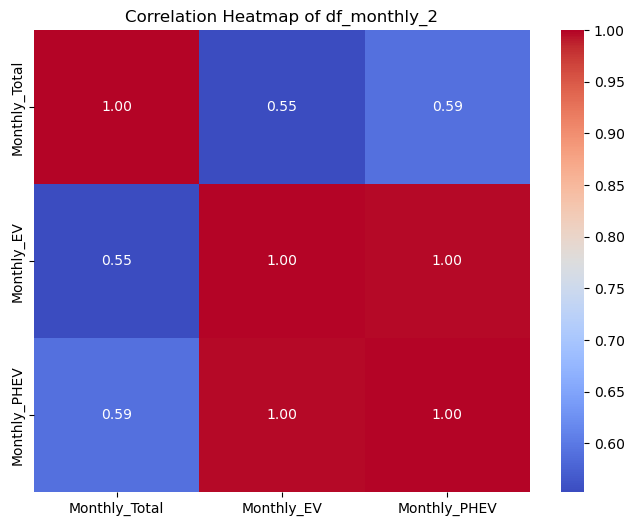

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix (excluding last two columns)
corr_matrix = df_monthly_2.set_index("Date").iloc[:, :-2].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

plt.title("Correlation Heatmap of df_monthly_2")
plt.show()

In [152]:
df_monthly= df_monthly_2.iloc[:, :-2]

# Define crises with start and end dates
crises_periods = {
    "Global_Financial_Crisis_Recovery": ("2010-01-01", "2011-12-31"),  # recovery period after 2008 crisis
    "Oil_Price_Crash": ("2014-06-01", "2016-01-31"),                    # oil price dropped
    "COVID19_Pandemic": ("2020-03-01", "2021-12-31"),                   # pandemic effect
    "Semiconductor_Shortage": ("2021-01-01", "2022-12-31"),             # global chip shortage
    "Energy_Crisis": ("2022-02-01", "2022-12-31"),                       # energy/gas price spike
}

# Initialize crisis columns with 0
for crisis in crises_periods.keys():
    df_monthly[crisis] = 0

# Fill 1 if the crisis was active
for crisis, (start, end) in crises_periods.items():
    start_date = pd.Timestamp(start)
    end_date = pd.Timestamp(end)
    df_monthly.loc[(df_monthly["Date"] >= start_date) & (df_monthly["Date"] <= end_date), crisis] = 1

In [153]:
df_monthly=df_monthly.merge(xls_elec,on=["Date"],how="inner")
df_monthly

,Date,Monthly_Total,Monthly_EV,Monthly_PHEV,Global_Financial_Crisis_Recovery,Oil_Price_Crash,COVID19_Pandemic,Semiconductor_Shortage,Energy_Crisis,Monthly_EV_market_share%,Monthly_PHEV_market_share%
0,2010-12-01,1138500.0,22770.0,11385.0,1,0,0,0,0,0.000017,0.000285
1,2011-01-01,807680.0,24230.4,12115.2,1,0,0,0,0,0.000126,0.000391
2,2011-02-01,848640.0,25459.2,12729.6,1,0,0,0,0,0.000084,0.000283
3,2011-03-01,1073920.0,32217.6,16108.8,1,0,0,0,0,0.000239,0.000488
4,2011-04-01,985600.0,29568.0,14784.0,1,0,0,0,0,0.000495,0.000426
...,...,...,...,...,...,...,...,...,...,...,...
139,2022-08-01,1205410.0,180811.5,84378.7,0,0,0,1,1,0.053009,0.012317
140,2022-09-01,1370800.0,205620.0,95956.0,0,0,0,1,1,0.062316,0.012064
141,2022-10-01,1338020.0,200703.0,93661.4,0,0,0,1,1,0.059223,0.014781
142,2022-11-01,1321630.0,198244.5,92514.1,0,0,0,1,1,0.055203,0.013800


In [154]:
df_monthly["ev_share"]= df_monthly["Monthly_Total"]*df_monthly["Monthly_EV_market_share%"]
df_monthly["phev_share"]= df_monthly["Monthly_Total"]*df_monthly["Monthly_PHEV_market_share%"]

df_monthly.drop(columns=["Monthly_EV","Monthly_PHEV"],inplace=True)

df_monthly

,Date,Monthly_Total,Global_Financial_Crisis_Recovery,Oil_Price_Crash,COVID19_Pandemic,Semiconductor_Shortage,Energy_Crisis,Monthly_EV_market_share%,Monthly_PHEV_market_share%,ev_share,phev_share
0,2010-12-01,1138500.0,1,0,0,0,0,0.000017,0.000285,18.894780,324.194647
1,2011-01-01,807680.0,1,0,0,0,0,0.000126,0.000391,101.460159,316.201079
2,2011-02-01,848640.0,1,0,0,0,0,0.000084,0.000283,70.895459,240.019566
3,2011-03-01,1073920.0,1,0,0,0,0,0.000239,0.000488,256.706806,523.750798
4,2011-04-01,985600.0,1,0,0,0,0,0.000495,0.000426,487.723589,419.629545
...,...,...,...,...,...,...,...,...,...,...,...
139,2022-08-01,1205410.0,0,0,0,1,1,0.053009,0.012317,63897.760084,14847.413867
140,2022-09-01,1370800.0,0,0,0,1,1,0.062316,0.012064,85422.747077,16536.817630
141,2022-10-01,1338020.0,0,0,0,1,1,0.059223,0.014781,79241.628950,19777.155424
142,2022-11-01,1321630.0,0,0,0,1,1,0.055203,0.013800,72957.494661,18237.905991


In [155]:
import pandas as pd
import numpy as np

def create_features(df):

    df = df.copy()
    
    # ---- time features ----
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date")
    
    df["year"] = df["Date"].dt.year
    df["month"] = df["Date"].dt.month
    df["quarter"] = df["Date"].dt.quarter
    
    # cyclic encoding (better for tree models)
    df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
    df["month_cos"] = np.cos(2*np.pi*df["month"]/12)
    
    
    # ---- EV adoption trend ----
    df["plugin_share_total"] = df["ev_share"] + df["phev_share"]
    
    
    # ---- lag features ----
    for lag in [1,2,3,6,12]:
        df[f"total_lag_{lag}"] = df["Monthly_Total"].shift(lag)
        df[f"ev_lag_{lag}"] = df["ev_share"].shift(lag)
        df[f"phev_lag_{lag}"] = df["phev_share"].shift(lag)
    
    
    # ---- rolling features ----
    df["total_roll3"] = df["Monthly_Total"].rolling(3).mean()
    df["total_roll6"] = df["Monthly_Total"].rolling(6).mean()
    
    df["ev_roll3"] = df["ev_share"].rolling(3).mean()
    df["ev_roll6"] = df["ev_share"].rolling(6).mean()
    
    
    # ---- growth features ----
    df["total_mom_growth"] = df["Monthly_Total"].pct_change()
    df["ev_mom_growth"] = df["ev_share"].pct_change()
    
    
    # ---- EV vs PHEV ratio ----
    df["ev_phev_ratio"] = df["ev_share"] / (df["phev_share"] + 1e-6)
    
    
    # ---- crisis intensity feature ----
    crisis_cols = [
        "Global_Financial_Crisis_Recovery",
        "Oil_Price_Crash",
        "COVID19_Pandemic",
        "Semiconductor_Shortage",
        "Energy_Crisis"
    ]
    
    df["crisis_total"] = df[crisis_cols].sum(axis=1)
    
    
    return df

def build_ev_features(df):

    # -----------------------------
    # PLUG-IN ADOPTION FEATURES
    # -----------------------------
    df["plugin_total"] = df["ev_share"] + df["phev_share"]

    df["ev_ratio"] = df["ev_share"] / (df["plugin_total"] + 1e-6)
    df["phev_ratio"] = df["phev_share"] / (df["plugin_total"] + 1e-6)

    df["ev_phev_ratio"] = df["ev_share"] / (df["phev_share"] + 1e-6)

    # -----------------------------
    # LAG FEATURES
    # -----------------------------
    lags = [1,2,3,6,12]

    for lag in lags:
        df[f"total_lag_{lag}"] = df["Monthly_Total"].shift(lag)
        df[f"ev_lag_{lag}"] = df["ev_share"].shift(lag)
        df[f"phev_lag_{lag}"] = df["phev_share"].shift(lag)
        df[f"plugin_lag_{lag}"] = df["plugin_total"].shift(lag)

    # -----------------------------
    # ROLLING FEATURES
    # -----------------------------
    windows = [3,6,12]

    for w in windows:
        df[f"total_roll_mean_{w}"] = df["Monthly_Total"].rolling(w).mean()
        df[f"total_roll_std_{w}"] = df["Monthly_Total"].rolling(w).std()

        df[f"ev_roll_mean_{w}"] = df["ev_share"].rolling(w).mean()
        df[f"plugin_roll_mean_{w}"] = df["plugin_total"].rolling(w).mean()

    # -----------------------------
    # MOMENTUM / GROWTH FEATURES
    # -----------------------------
    df["total_mom_growth"] = df["Monthly_Total"].pct_change()
    df["ev_mom_growth"] = df["ev_share"].pct_change()
    df["plugin_mom_growth"] = df["plugin_total"].pct_change()

    # -----------------------------
    # TREND FEATURES
    # -----------------------------
    df["trend_index"] = np.arange(len(df))

    # -----------------------------
    # CRISIS INTENSITY FEATURE
    # -----------------------------
    crisis_cols = [
        "Global_Financial_Crisis_Recovery",
        "Oil_Price_Crash",
        "COVID19_Pandemic",
        "Semiconductor_Shortage",
        "Energy_Crisis"
    ]

    df["crisis_count"] = df[crisis_cols].sum(axis=1)

    # -----------------------------
    # CLEAN DATA
    # -----------------------------
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna()

    return df

# df_monthly = create_features(df_monthly)
# df_monthly = build_ev_features(df_monthly)

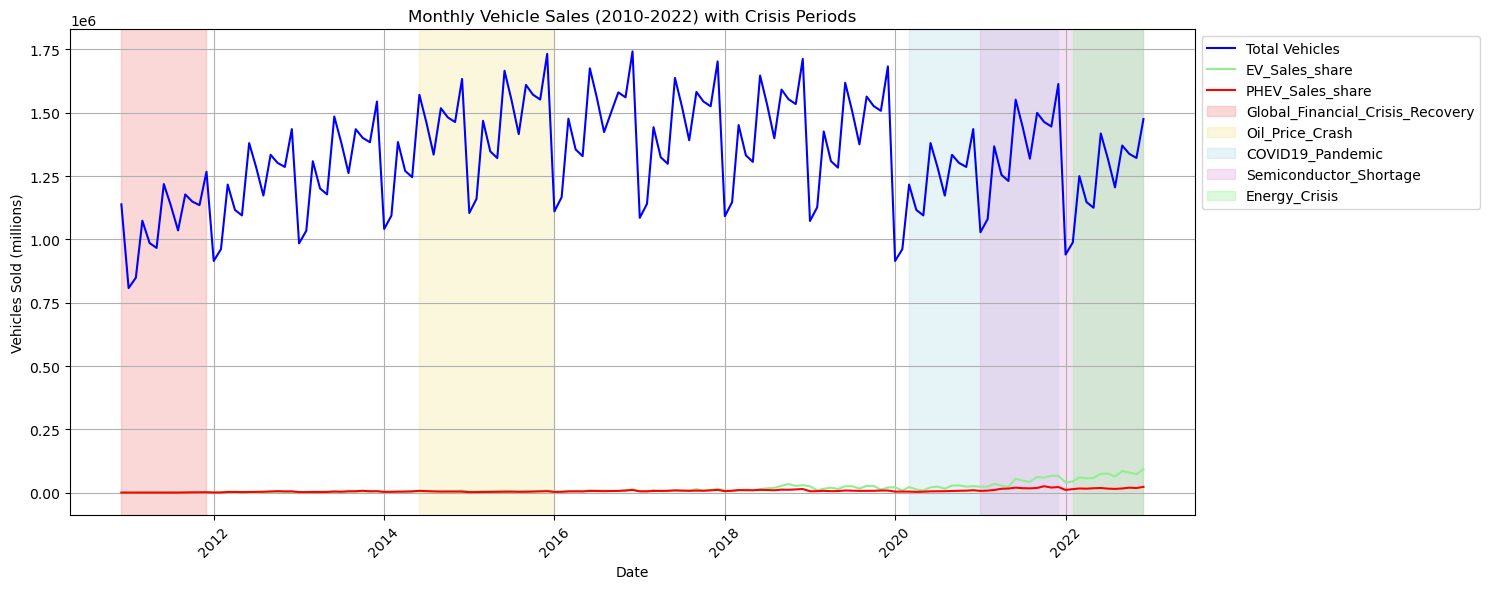

In [156]:
# Plot heatmap
# plt.figure(figsize=(8,6))
# sns.heatmap(df_monthly.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

# plt.title("Correlation Heatmap of df_monthly_2")
# plt.show()

import matplotlib.pyplot as plt

# Set figure size
plt.figure(figsize=(15,6))

# Plot sales lines
plt.plot(df_monthly["Date"], df_monthly["Monthly_Total"], label="Total Vehicles", color="blue")
# plt.plot(df_monthly["Date"], df_monthly["Monthly_EV"], label="EV Sales", color="green")
# plt.plot(df_monthly["Date"], df_monthly["Monthly_PHEV"], label="PHEV Sales", color="orange")
plt.plot(df_monthly["Date"], df_monthly["ev_share"], label="EV_Sales_share", color="lightgreen")
plt.plot(df_monthly["Date"], df_monthly["phev_share"], label="PHEV_Sales_share", color="red")

# Crisis periods for shading
crises_colors = {
    "Global_Financial_Crisis_Recovery": "lightcoral",
    "Oil_Price_Crash": "khaki",
    "COVID19_Pandemic": "lightblue",
    "Semiconductor_Shortage": "plum",
    "Energy_Crisis": "lightgreen"
}

# Add shaded regions for each crisis
for crisis, color in crises_colors.items():
    # find start and end dates
    active_dates = df_monthly[df_monthly[crisis]==1]["Date"]
    if not active_dates.empty:
        plt.axvspan(active_dates.min(), active_dates.max(), color=color, alpha=0.3, label=crisis)

# Chart styling
plt.title("Monthly Vehicle Sales (2010-2022) with Crisis Periods")
plt.xlabel("Date")
plt.ylabel("Vehicles Sold (millions)")
plt.legend(loc="upper left", bbox_to_anchor=(1,1))  # move legend outside
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [157]:
year_df=df_monthly[["Date", "Monthly_EV_market_share%", "Monthly_PHEV_market_share%"]]

year_df["ev_share_log"] = np.log1p(year_df["Monthly_EV_market_share%"])
year_df["phev_share_log"] = np.log1p(year_df["Monthly_PHEV_market_share%"])

year_df=year_df[["Date", "ev_share_log", "phev_share_log"]]
year_df

,Date,ev_share_log,phev_share_log
0,2010-12-01,0.000017,0.000285
1,2011-01-01,0.000126,0.000391
2,2011-02-01,0.000084,0.000283
3,2011-03-01,0.000239,0.000488
4,2011-04-01,0.000495,0.000426
...,...,...,...
139,2022-08-01,0.051652,0.012242
140,2022-09-01,0.060451,0.011991
141,2022-10-01,0.057536,0.014673
142,2022-11-01,0.053733,0.013705


In [158]:
# use  for "ev_share" estimator = TBATS(
                #     seasonal_periods=12,
                #     use_box_cox=False,
                #     use_trend=True,
                #     use_damped_trend=False
                # )

# for "phev_share" keep the same as below 


# year_df=df_monthly[["Date", "ev_share", "phev_share"]]  

# year_df = year_df.tail(12)

from statsmodels.tsa.holtwinters import ExponentialSmoothing

year_df["Date"] = pd.to_datetime(year_df["Date"])
year_df = year_df.set_index("Date")
year_df = year_df.asfreq("MS")

year_df_numeric = year_df.select_dtypes(include="number")

# year_df_numeric= year_df_numeric.tail(36)

forecast_all = {}

for col in year_df_numeric.columns:

    series = year_df_numeric[col].dropna()

    model = ExponentialSmoothing(
        series,
        trend="additive",
        seasonal=None,
    ).fit()

    # model = ExponentialSmoothing(
    #     series,
    #     trend="add",
    #     damped_trend=True,
    #     seasonal="mul",
    #     seasonal_periods=12
    # ).fit()

    pred = model.forecast(12)

    forecast_all[col] = pred.values


# 1. Your input dictionary
data_dict = forecast_all

# 2. Create the Date index for 2023
# 'MS' stands for Month Start (2023-01-01, 2023-02-01, etc.)
dates = pd.date_range(start='2023-01-01', periods=12, freq='MS')

# 3. Initialize the DataFrame
forcast_df = pd.DataFrame(data_dict)

# 4. Insert the Date column and set it as the index
forcast_df['Date'] = dates
forcast_df = forcast_df[['Date', 'ev_share_log', 'phev_share_log']] # Reordering columns

# 5. Display the result
print(forcast_df)

         Date  ev_share_log  phev_share_log
0  2023-01-01      0.061282        0.015214
1  2023-02-01      0.062758        0.015318
2  2023-03-01      0.064234        0.015422
3  2023-04-01      0.065709        0.015526
4  2023-05-01      0.067185        0.015630
5  2023-06-01      0.068661        0.015733
6  2023-07-01      0.070137        0.015837
7  2023-08-01      0.071613        0.015941
8  2023-09-01      0.073089        0.016045
9  2023-10-01      0.074565        0.016149
10 2023-11-01      0.076041        0.016253
11 2023-12-01      0.077517        0.016357


In [159]:
forcast_df["ev_share"] = np.expm1(forcast_df["ev_share_log"])
forcast_df["phev_share"] = np.expm1(forcast_df["phev_share_log"])
forcast_df

,Date,ev_share_log,phev_share_log,ev_share,phev_share
0,2023-01-01,0.061282,0.015214,0.063198,0.015330
1,2023-02-01,0.062758,0.015318,0.064769,0.015436
2,2023-03-01,0.064234,0.015422,0.066341,0.015541
3,2023-04-01,0.065709,0.015526,0.067916,0.015647
4,2023-05-01,0.067185,0.015630,0.069494,0.015752
5,2023-06-01,0.068661,0.015733,0.071073,0.015858
6,2023-07-01,0.070137,0.015837,0.072655,0.015964
7,2023-08-01,0.071613,0.015941,0.074240,0.016069
8,2023-09-01,0.073089,0.016045,0.075827,0.016175
9,2023-10-01,0.074565,0.016149,0.077416,0.016280


In [160]:
forcast_df=forcast_df.set_index("Date")

In [161]:
df_month=df_month[["Vehicles Sold (millions)"]]

In [162]:
forcast_df["ev"]=forcast_df["ev_share"]* df_month["Vehicles Sold (millions)"]
forcast_df["phev"]=forcast_df["phev_share"]* df_month["Vehicles Sold (millions)"]
forcast_df

,ev_share_log,phev_share_log,ev_share,phev_share,ev,phev
Date,,,,,,
2023-01-01,0.061282,0.015214,0.063198,0.015330,68989.156705,16734.669315
2023-02-01,0.062758,0.015318,0.064769,0.015436,74289.030540,17704.413384
2023-03-01,0.064234,0.015422,0.066341,0.015541,96292.532554,22557.460530
2023-04-01,0.065709,0.015526,0.067916,0.015647,90471.455584,20842.963424
2023-05-01,0.067185,0.015630,0.069494,0.015752,90769.285620,20574.851811
2023-06-01,0.068661,0.015733,0.071073,0.015858,117055.132967,26117.314636
2023-07-01,0.070137,0.015837,0.072655,0.015964,111364.850379,24468.544783
2023-08-01,0.071613,0.015941,0.074240,0.016069,103903.829372,22489.876697
2023-09-01,0.073089,0.016045,0.075827,0.016175,120685.484743,25743.763870


In [136]:
import pandas as pd
from pmdarima import auto_arima
from tbats import TBATS
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# # Select columns
# year_df = df_monthly[["Date", "ev_share", "phev_share"]]

# # Convert date first
# year_df["Date"] = pd.to_datetime(year_df["Date"])

# # Set index
# year_df = year_df.set_index("Date")

# # Ensure monthly frequency
# year_df = year_df.asfreq("MS")

# # Fill missing values (important after asfreq)
# year_df[["ev_share", "phev_share"]] = (
#     year_df[["ev_share", "phev_share"]]
#     .interpolate(method="time")
#     .ffill()
#     .bfill()
# )

# # Keep numeric columns
# year_df_numeric = year_df.select_dtypes(include="number")
import pandas as pd
from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller


# -----------------------------
# Log transform
# -----------------------------
df_monthly["ev_share_log"] = np.log1p(df_monthly["ev_share"])
df_monthly["phev_share_log"] = np.log1p(df_monthly["phev_share"])

# -----------------------------
# Columns
# -----------------------------
target_cols = ["ev_share_log", "phev_share_log"]

crisis_cols = [
    "Global_Financial_Crisis_Recovery",
    "Oil_Price_Crash",
    "COVID19_Pandemic",
    "Semiconductor_Shortage",
    "Energy_Crisis",
    "Monthly_Total"
]

# -----------------------------
# Build dataframe
# -----------------------------
year_df = df_monthly[["Date"] + target_cols + crisis_cols].copy()

year_df["Date"] = pd.to_datetime(year_df["Date"])
year_df = year_df.set_index("Date")
year_df = year_df.asfreq("MS")

# -----------------------------
# Fill missing values
# -----------------------------
year_df[target_cols] = (
    year_df[target_cols]
    .interpolate(method="time")
    .ffill()
    .bfill()
)

year_df[crisis_cols] = (
    year_df[crisis_cols]
    .interpolate(method="time")
    .ffill()
    .bfill()
)

# -----------------------------
# ADF test
# -----------------------------
for col in target_cols:

    series = year_df[col]
    result = adfuller(series)

    print(f"\n===== {col} =====")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    if result[1] <= 0.05:
        print("Result: Stationary")
    else:
        print("Result: Non-Stationary")

# -----------------------------
# Train models
# -----------------------------
forecast_all = {}

for col in target_cols:

    y = year_df[col]
    X = year_df[crisis_cols]

    model = auto_arima(
        y,
        exogenous=X,
        seasonal=True,
        m=12,
        stepwise=True,
        suppress_warnings=True,
        trace=False
    )

    # -----------------------------
    # Future exogenous values
    # -----------------------------
    X_future = X.tail(12).copy()

    pred = model.predict(
        n_periods=12,
        exogenous=X_future
    )

    forecast_all[col] = pred

# -----------------------------
# Forecast dataframe
# -----------------------------
dates = pd.date_range(start="2023-01-01", periods=12, freq="MS")

forecast_df = pd.DataFrame(forecast_all)
forecast_df["Date"] = dates
forecast_df = forecast_df[["Date", "ev_share_log", "phev_share_log"]]

# -----------------------------
# Convert back from log
# -----------------------------
forecast_df["ev_share"] = np.expm1(forecast_df["ev_share_log"])
forecast_df["phev_share"] = np.expm1(forecast_df["phev_share_log"])

print(forecast_df)



===== ev_share_log =====
ADF Statistic: -0.9081993118872306
p-value: 0.7852602754439697
Result: Non-Stationary

===== phev_share_log =====
ADF Statistic: -3.028243366268326
p-value: 0.032339689680848195
Result: Stationary



KeyboardInterrupt



In [ ]:
# for col in year_df_numeric.columns:

#     series = year_df_numeric[col].dropna()

#     # ----- EV MODEL -----

#     estimator = TBATS(
#         seasonal_periods=[12],
#         use_box_cox=False,
#         use_trend=True,
#         use_damped_trend=False
#     )

#     model = estimator.fit(series)
#     pred = model.forecast(steps=12)

#     forecast_all[col] = pred


# # 1️⃣ Forecast dictionary
# data_dict = forecast_all

# # 2️⃣ Create 2023 monthly dates
# dates = pd.date_range(start='2023-01-01', periods=12, freq='MS')

# # 3️⃣ Create DataFrame
# forcast_df = pd.DataFrame(data_dict)

# # 4️⃣ Insert Date column
# forcast_df['Date'] = dates
# forcast_df = forcast_df[['Date', 'ev_share', 'phev_share']]

# # 5️⃣ Display result
# print(forcast_df)



import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pmdarima import auto_arima
from tbats import TBATS
from statsmodels.tsa.holtwinters import ExponentialSmoothing


def walk_forward_backtest(
        data,
        exog=None,
        model_type="auto_arima",
        start_train="2020-01-01",
        start_test="2022-01-01",
        seasonal_periods=[12]
    ):

    data = data.copy()
    exog = exog.copy() if exog is not None else None

    predictions = {col: [] for col in data.columns}
    actuals = {col: [] for col in data.columns}
    dates = []

    test_dates = data.loc[start_test:].index

    for current_date in test_dates:

        train = data.loc[start_train:current_date - pd.offsets.MonthBegin(1)]

        if exog is not None:
            X_train = exog.loc[start_train:current_date - pd.offsets.MonthBegin(1)]
            X_test = exog.loc[[current_date]]
        else:
            X_train = None
            X_test = None

        for col in data.columns:

            series = train[col].dropna()

            # -------------------------
            # MODEL SELECTION
            # -------------------------
            if model_type == "auto_arima":

                model = auto_arima(
                    series,
                    exogenous=X_train,
                    seasonal=False,
                    m=12,
                    stepwise=True,
                    suppress_warnings=True,
                    error_action="ignore"
                )

                pred = model.predict(
                    n_periods=1,
                    exogenous=X_test
                )[0]

            elif model_type == "tbats":

                estimator = TBATS(
                    seasonal_periods=seasonal_periods,
                    use_box_cox=False,
                    use_trend=True,
                    use_damped_trend=False
                )

                model = estimator.fit(series)
                pred = model.forecast(steps=1)[0]

            elif model_type == "ets":

                model = ExponentialSmoothing(
                    series,
                    trend="add",
                    seasonal=None
                ).fit()

                pred = model.forecast(1)[0]

            else:
                raise ValueError("Unknown model")

            predictions[col].append(pred)
            actuals[col].append(data.loc[current_date, col])

        dates.append(current_date)

    pred_df = pd.DataFrame(predictions, index=dates)
    actual_df = pd.DataFrame(actuals, index=dates)

    # -------------------------
    # Plot
    # -------------------------
    plt.figure(figsize=(12,6))

    for col in data.columns:
        plt.plot(data.index, data[col], label=f"{col} actual")
        plt.plot(pred_df.index, pred_df[col], "--", label=f"{col} forecast")

    plt.title(f"Walk-Forward Backtest ({model_type})")
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.legend()
    plt.show()

    # -------------------------
    # Metrics
    # -------------------------
    print("\nBacktest Metrics")

    for col in data.columns:
        mape = (np.abs((actual_df[col] - pred_df[col]) / actual_df[col])).mean() * 100
        print(f"{col}: MAPE = {mape:.2f}%")

    return pred_df, actual_df

pred_df, actual_df = walk_forward_backtest(
    year_df[["ev_share_log","phev_share_log"]],
    exog=year_df[crisis_cols],
    # model_type="ets"
)

In [ ]:
# model.summary()

In [163]:
# from prophet import Prophet

# # ensure datetime
# year_df["Date"] = pd.to_datetime(year_df["Date"])

# # regressors list
# regressors = [
#     # "Global_Financial_Crisis_Recovery",
#     # "Oil_Price_Crash",
#     # "COVID19_Pandemic",
#     # "Semiconductor_Shortage",
#     # "Energy_Crisis"
# ]

# # -------------------------
# # EV dataset
# # -------------------------
# ev_df = year_df.rename(columns={
#     "Date": "ds",
#     "ev_share": "y"
# })[["ds", "y"] + regressors]


# # -------------------------
# # PHEV dataset
# # -------------------------
# phev_df = year_df.rename(columns={
#     "Date": "ds",
#     "phev_share": "y"
# })[["ds", "y"] + regressors]


# # -------------------------
# # EV model
# # -------------------------
# ev_model = Prophet()

# for r in regressors:
#     ev_model.add_regressor(r)

# ev_model.fit(ev_df)


# # -------------------------
# # PHEV model
# # -------------------------
# phev_model = Prophet()

# for r in regressors:
#     phev_model.add_regressor(r)

# phev_model.fit(phev_df)


# # -------------------------
# # future dataframe
# # -------------------------
# ev_future = ev_model.make_future_dataframe(periods=12, freq="MS")
# phev_future = phev_model.make_future_dataframe(periods=12, freq="MS")


# # merge external factors
# reg_df = year_df[["Date"] + regressors].rename(columns={"Date": "ds"})

# ev_future = ev_future.merge(reg_df, on="ds", how="left")
# phev_future = phev_future.merge(reg_df, on="ds", how="left")


# # fill future values
# for r in regressors:
#     ev_future[r] = ev_future[r].ffill()
#     phev_future[r] = phev_future[r].ffill()


# # -------------------------
# # prediction
# # -------------------------
# ev_forecast = ev_model.predict(ev_future)
# phev_forecast = phev_model.predict(phev_future)


# # -------------------------
# # combine forecast
# # -------------------------
# forecast = pd.DataFrame({
#     "Date": ev_forecast["ds"],
#     "ev_share_pred": ev_forecast["yhat"],
#     "phev_share_pred": phev_forecast["yhat"]
# })


# # -------------------------
# # plots
# # -------------------------
# ev_model.plot(ev_forecast)
# phev_model.plot(phev_forecast)

In [164]:
# forecast_prophet=forecast.tail(12).set_index("Date").rename(columns={"ev_share_pred":"ev_share","phev_share_pred":"phev_share"})
# forecast_prophet

In [165]:
# forecast_all = {}

# for col in year_df_numeric.columns:
#     series = year_df_numeric[col].dropna()
    
#     # Initialize TBATS model
#     estimator = TBATS(
#         seasonal_periods=[4,6,12,24],  # monthly seasonality
#         use_box_cox=True,
#         use_trend=True,
#         use_damped_trend=True
#     )
    
#     # Fit the model
#     model = estimator.fit(series)
    
#     # Forecast next 12 months
#     pred = model.forecast(steps=12)
    
#     forecast_all[col] = pred

# # --- Convert forecast dictionary to a DataFrame with Date index for 2023 ---
# dates = pd.date_range(start='2023-01-01', periods=12, freq='MS')

# forcast_df = pd.DataFrame(forecast_all)
# forcast_df['Date'] = dates
# forcast_df = forcast_df[['Date', 'ev_share', 'phev_share']]  # reorder columns

# print(forcast_df)

In [166]:
df_monthly

,Date,Monthly_Total,Global_Financial_Crisis_Recovery,Oil_Price_Crash,COVID19_Pandemic,Semiconductor_Shortage,Energy_Crisis,Monthly_EV_market_share%,Monthly_PHEV_market_share%,ev_share,phev_share
0,2010-12-01,1138500.0,1,0,0,0,0,0.000017,0.000285,18.894780,324.194647
1,2011-01-01,807680.0,1,0,0,0,0,0.000126,0.000391,101.460159,316.201079
2,2011-02-01,848640.0,1,0,0,0,0,0.000084,0.000283,70.895459,240.019566
3,2011-03-01,1073920.0,1,0,0,0,0,0.000239,0.000488,256.706806,523.750798
4,2011-04-01,985600.0,1,0,0,0,0,0.000495,0.000426,487.723589,419.629545
...,...,...,...,...,...,...,...,...,...,...,...
139,2022-08-01,1205410.0,0,0,0,1,1,0.053009,0.012317,63897.760084,14847.413867
140,2022-09-01,1370800.0,0,0,0,1,1,0.062316,0.012064,85422.747077,16536.817630
141,2022-10-01,1338020.0,0,0,0,1,1,0.059223,0.014781,79241.628950,19777.155424
142,2022-11-01,1321630.0,0,0,0,1,1,0.055203,0.013800,72957.494661,18237.905991


In [167]:
from sktime.forecasting.compose import RecursiveTabularRegressionForecaster
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.model_selection import ExpandingWindowSplitter
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor

df = df_monthly.copy()

df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")

# important for sktime
df = df.asfreq("MS")

df[["ev_share_log","phev_share_log"]] = df[["ev_share_log","phev_share_log"]].interpolate()

# targets
y = df[["ev_share_log","phev_share_log"]]

# predictors
X = df.drop(columns=["ev_share_log","phev_share_log"])



from sktime.forecasting.base import ForecastingHorizon

fh = ForecastingHorizon(range(1,13), is_relative=True)

model = RecursiveTabularRegressionForecaster(
    estimator=RandomForestRegressor(
        n_estimators=500,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    ),
    window_length=12
)

# from xgboost import XGBRegressor

# model = RecursiveTabularRegressionForecaster(
#     estimator=XGBRegressor(
#         n_estimators=500,
#         max_depth=6,
#         learning_rate=0.05,
#         subsample=0.9,
#         colsample_bytree=0.9,
#         random_state=42,
#         n_jobs=-1
#     ),
#     window_length=12
# )

cv = ExpandingWindowSplitter(
    initial_window=24,
    step_length=12,
    fh=range(1,13)
)

mape_scores = []

for train_idx, test_idx in cv.split(y):

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    model.fit(y_train, X=X_train)

    pred = model.predict(fh, X=X_test)

    mape = mean_absolute_percentage_error(y_test, pred)

    mape_scores.append(mape)

print("MAPE per fold:", mape_scores)
print("Mean MAPE:", np.mean(mape_scores))

KeyError: "None of [Index(['ev_share_log', 'phev_share_log'], dtype='object')] are in the [columns]"

In [ ]:
from sktime.forecasting.compose import RecursiveTabularRegressionForecaster
from sklearn.ensemble import RandomForestRegressor

from sktime.forecasting.compose import RecursiveTabularRegressionForecaster
from lightgbm import LGBMRegressor

# model = RecursiveTabularRegressionForecaster(
#     estimator=LGBMRegressor(
#         n_estimators=500,
#         learning_rate=0.05,
#         max_depth=6,
#         random_state=42
#     ),
#     window_length=12
# )


model.fit(y=y, X=X)


future_index = pd.date_range(
    start=df.index[-1] + pd.offsets.MonthBegin(),
    periods=12,
    freq="MS"
)

X_future = pd.DataFrame(
    X.iloc[-1].values.repeat(12).reshape(12,-1),
    columns=X.columns,
    index=future_index
)

y_pred = model.predict(fh=fh, X=X_future)

print(y_pred)

In [168]:
y_pred["ev_share"] = np.expm1(y_pred["ev_share_log"])
y_pred["phev_share"] = np.expm1(y_pred["phev_share_log"])
y_pred

NameError: name 'y_pred' is not defined

In [22]:
# from sktime.forecasting.sarimax import SARIMAX

# import numpy as np
# import pandas as pd
# from sktime.forecasting.sarimax import SARIMAX
# from sktime.forecasting.base import ForecastingHorizon

# # -----------------------
# # 1. Clean exogenous data
# # -----------------------
# X = (
#     X.replace([np.inf, -np.inf], np.nan)
#      .ffill()
#      .bfill()
# )

# # -----------------------
# # 2. Convert index to PeriodIndex
# # -----------------------
# y.index = pd.PeriodIndex(y.index, freq="M")
# X.index = pd.PeriodIndex(X.index, freq="M")
# X_future.index = pd.PeriodIndex(X_future.index, freq="M")

# # -----------------------
# # 3. Forecast horizon
# # -----------------------
# fh = ForecastingHorizon(
#     np.arange(1, len(X_future) + 1),
#     is_relative=True
# )

# # -----------------------
# # 4. Train model
# # -----------------------
# model = SARIMAX(
#     order=(2,1,2),
#     seasonal_order=(1,1,1,12)
# )

# model.fit(y=y, X=X)

# # -----------------------
# # 5. Forecast
# # -----------------------
# y_pred = model.predict(fh=fh, X=X_future)

# print(y_pred)

In [23]:
# y_pred  #0. 0.5518

In [24]:
# forecast_all  # 0.3353

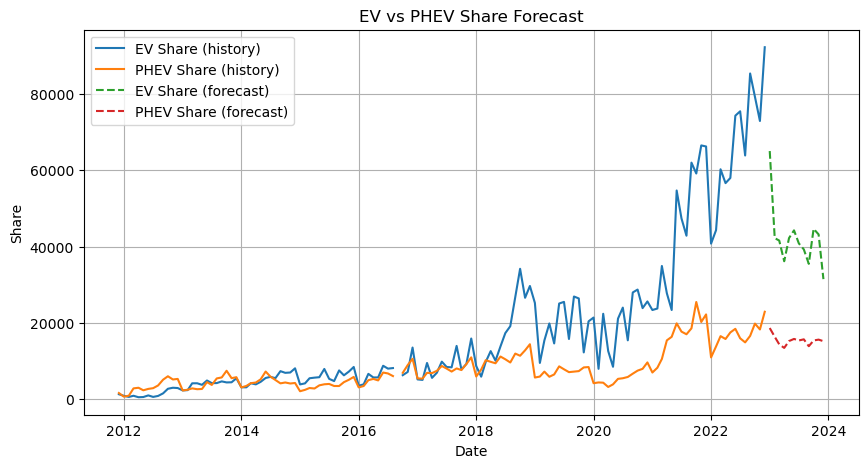

In [85]:
import matplotlib.pyplot as plt

# combine historical shares with predictions
df_plot = pd.concat([df[["ev_share","phev_share"]], y_pred[["ev_share","phev_share"]]], axis=0)

# historical data
plt.figure(figsize=(10,5))
plt.plot(df.index, df["ev_share"], label="EV Share (history)")
plt.plot(df.index, df["phev_share"], label="PHEV Share (history)")

# forecast data (dashed)
plt.plot(y_pred.index, y_pred["ev_share"], "--", label="EV Share (forecast)")
plt.plot(y_pred.index, y_pred["phev_share"], "--", label="PHEV Share (forecast)")

plt.title("EV vs PHEV Share Forecast")
plt.xlabel("Date")
plt.ylabel("Share")
plt.legend()
plt.grid(True)

plt.show()

In [170]:
import pandas as pd

forecast = forcast_df[["ev","phev"]]
    
months = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

rows = []

# EV rows
for m, v in zip(months, forecast["ev"]):
    rows.append({"Periodo": f"{m}-EV", "Ventas": v})

# PHEV rows
for m, v in zip(months, forecast["phev"]):
    rows.append({"Periodo": f"{m}-PHEV", "Ventas": v})

df_final = pd.DataFrame(rows)

print(df_final)

     Periodo         Ventas
0     Ene-EV   68989.156705
1     Feb-EV   74289.030540
2     Mar-EV   96292.532554
3     Abr-EV   90471.455584
4     May-EV   90769.285620
5     Jun-EV  117055.132967
6     Jul-EV  111364.850379
7     Ago-EV  103903.829372
8     Sep-EV  120685.484743
9     Oct-EV  120268.160936
10    Nov-EV  121236.938584
11    Dic-EV  138044.775367
12  Ene-PHEV   16734.669315
13  Feb-PHEV   17704.413384
14  Mar-PHEV   22557.460530
15  Abr-PHEV   20842.963424
16  May-PHEV   20574.851811
17  Jun-PHEV   26117.314636
18  Jul-PHEV   24468.544783
19  Ago-PHEV   22489.876697
20  Sep-PHEV   25743.763870
21  Oct-PHEV   25292.280183
22  Nov-PHEV   25144.598267
23  Dic-PHEV   28245.413825


In [171]:
from datetime import datetime

time = datetime.now().strftime("%Y%m%d_%H%M%S")

df_final.to_csv("submission_surv_{}.csv".format(time), index=False)